# WOE Binning and Variable Selection

## Objective
This notebook performs Weight of Evidence (WOE) binning for candidate
predictor variables used in a Probability of Default (PD) model.

Each variable is:
- Binned logically
- Checked for monotonic relationship with default
- Evaluated using Information Value (IV)
- Accepted or rejected based on statistical and business reasoning


In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<font size="4"> Load Cleaned Data into the excel

In [148]:
df = pd.read_csv('../data/processed/credit_data_cleaned.csv')
df.head(1)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,Dependents_missing,High_Delinquency_Flag,DebtRatio_high_flag
0,1,0.766127,45,2,0.802982,9120.0,13,0,5,0,2.0,0,0,0,0


In [149]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,Dependents_missing,High_Delinquency_Flag,DebtRatio_high_flag
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,0.319196,52.295007,0.263233,316.548869,6.418455e+03,8.438793,0.107920,1.002480,0.082633,0.737413,0.198207,0.026160,0.001933,0.010000
std,0.249746,0.349481,14.770418,0.809436,906.962222,1.289040e+04,5.070728,0.635481,1.020301,0.534148,1.107021,0.398650,0.159611,0.043927,0.099499
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,100.000000,10.000000,4979.040000,3.008750e+06,30.000000,10.000000,5.000000,10.000000,20.000000,1.000000,1.000000,1.000000,1.000000


In [150]:
df.columns.values

array(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
       'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents',
       'MonthlyIncome_missing', 'Dependents_missing',
       'High_Delinquency_Flag', 'DebtRatio_high_flag'], dtype=object)

In [151]:
df['SeriousDlqin2yrs'].unique()

array([1, 0], dtype=int64)

## Target Variable Definition

The target variable for the PD model is **SeriousDlqin2yrs**.

- Value = 1 → Borrower experienced serious delinquency (90+ DPD)
- Value = 0 → Borrower remained non-delinquent

The observed default rate in the dataset is approximately 6.6%, which
is realistic for a retail credit portfolio.


In [152]:
TARGET = 'SeriousDlqin2yrs'

In [153]:
df[TARGET].value_counts(normalize=True)


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

## Train–Test Split Before WOE Binning

### Purpose of Train–Test Split

In this project, the dataset is divided into **training** and **testing** samples
before performing Weight of Evidence (WOE) binning.

The training dataset is used to:
- Learn variable relationships with default
- Create WOE bins and mappings
- Estimate model parameters

The testing dataset is kept **completely unseen** until model validation.

---

### Why Train–Test Split Is Done Before WOE Binning

WOE binning is a **target-dependent transformation**.  
It uses the default indicator to:
- Calculate bad rates within bins
- Compute Weight of Evidence (WOE) values
- Assess Information Value (IV)

If WOE binning is performed on the **entire dataset before splitting**, information
from the test set would influence the binning process.  
This results in **data leakage**, where future or validation data indirectly affects
model development.

To prevent this:
- Train–test split is performed first
- WOE bins are learned **only on the training data**
- The learned WOE mappings are then applied to the test data

This ensures that model performance is evaluated on truly unseen data.

---

### Importance of Stratified Sampling

The observed default rate in the dataset is approximately **6.6%**.

During the train–test split, **stratified sampling** is used to:
- Preserve the same proportion of defaults and non-defaults
- Ensure stable model estimation and validation
- Avoid biased performance metrics due to class imbalance

---

### Modelling Principle Followed

> Any transformation that uses the target variable must be fitted
> only on the training dataset.

This principle applies to:
- WOE binning
- Logistic regression model training
- PD calibration

Following this sequence aligns with standard practices used in
regulated credit risk modelling environments.


In [154]:
from sklearn.model_selection import train_test_split

In [155]:
x = df.drop(columns = [TARGET])
y = df[TARGET]
x_train, x_test,y_train,y_test = train_test_split(x , y , test_size = 0.25 , random_state = 42, stratify=y)

In [156]:
train_data = x_train.copy()
train_data[TARGET] = y_train.copy()
test_data = x_test.copy()
test_data[TARGET] = y_test.copy()

### Sanity Check: Default Rate Consistency After Train–Test Split

After splitting the dataset, it is important to verify that the proportion
of defaulted and non-defaulted observations remains consistent across
the overall dataset, training sample, and test sample.

This check ensures that:
- Stratified sampling has been applied correctly
- The class imbalance (default rate ≈ 6.6%) is preserved
- The training and test datasets are representative of the same population

Preserving the default rate across samples is critical for:
- Stable WOE estimation
- Reliable PD model training
- Meaningful out-of-sample validation results


In [157]:
print("Overall default rate :", df[TARGET].mean())
print("Train default rate   :", train_data[TARGET].mean())
print("Test default rate    :", test_data[TARGET].mean())


Overall default rate : 0.06684
Train default rate   : 0.06684444444444444
Test default rate    : 0.06682666666666667


## WOE Binning for Variable: age

### Why WOE Binning Is Used in Credit Risk Models

Weight of Evidence (WOE) is a transformation technique widely used in
credit risk modelling, especially with logistic regression models.

WOE transformation helps to:
- Capture the relationship between a predictor and default risk
- Handle non-linear relationships in a structured way
- Reduce the impact of outliers
- Improve model interpretability and stability

In a WOE-based PD model, each bin of a variable is replaced by a single
numeric value (the WOE), which represents the relative risk of default
for that bin.

---

### Business Expectation for `age`

From a credit risk perspective:
- Younger borrowers are generally expected to have higher default risk
  due to lower income stability and shorter credit history
- Default risk is expected to decrease as borrower age increases

Therefore, for the variable `age`, we expect a **monotonic decreasing**
relationship between age and default rate.

---

### Why Binning Is Required Before WOE Calculation

WOE is not calculated at the individual observation level.
Instead, it is calculated at the **bin level**.

Each bin groups borrowers with similar values of `age`, and for each bin
we calculate:
- Number of good accounts (non-defaults)
- Number of bad accounts (defaults)
- Proportion of goods and bads
- Weight of Evidence (WOE)

The choice of bins directly affects:
- WOE stability
- Information Value (IV)
- Model robustness

---

### Initial Binning Strategy

For the `age` variable:
- Quantile-based binning is used initially to ensure sufficient
  observations in each bin
- This helps avoid unstable WOE values caused by very small bin sizes

The initial bins will be reviewed and adjusted to ensure:
- Logical ordering
- Monotonic relationship between age and default rate
- Stability of WOE values across bins

---

### Monotonicity Check

After initial binning, the default rate across age bins will be examined.

If the default rate:
- Decreases consistently with age → bins are considered monotonic
- Shows irregular patterns → bins may be merged or redefined

Monotonicity is important because:
- It aligns the model with business intuition
- It improves coefficient stability in logistic regression
- It reduces the risk of overfitting

---

### Information Value (IV)

Information Value (IV) is used to measure the predictive power of a variable.

As a general guideline:
- IV < 0.02 → Not predictive
- 0.02 ≤ IV < 0.1 → Weak predictor
- 0.1 ≤ IV < 0.3 → Medium predictor
- IV ≥ 0.3 → Strong predictor

IV will be calculated after finalizing the WOE bins to assess whether
`age` should be retained in the PD model.

---

### Scope of This Section

In the following steps:
- WOE bins will be finalized using **training data only**
- WOE values and IV will be calculated
- A clear decision will be documented on whether `age` is retained or dropped

The learned WOE mapping will later be applied unchanged to the test data
during model validation.


In [158]:
train_data['age'].describe()

count    112500.000000
mean         52.270293
std          14.761993
min          18.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         100.000000
Name: age, dtype: float64

In [159]:
train_data['age'].isnull().sum()

0

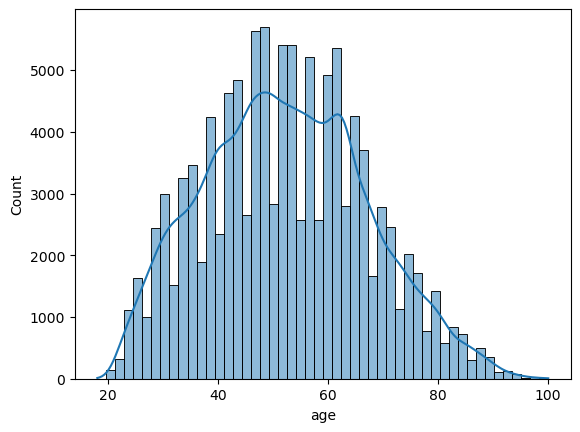

In [160]:
sns.histplot(train_data['age'], bins = 50, kde = True)
plt.show()

In [161]:
train_data['age_bin'] = pd.qcut(train_data['age'], q = 10 , duplicates = 'drop')
test_data['age_bin'] = pd.qcut(test_data['age'], q = 10 , duplicates = 'drop')

In [162]:
train_data['age_bin'].value_counts().sort_index()

age_bin
(17.999, 33.0]    12821
(33.0, 39.0]      11205
(39.0, 44.0]      11819
(44.0, 48.0]      11111
(48.0, 52.0]      11119
(52.0, 56.0]      10693
(56.0, 60.0]       9991
(60.0, 65.0]      12423
(65.0, 72.0]      10600
(72.0, 100.0]     10718
Name: count, dtype: int64

In [163]:
woe_df = train_data[['age_bin','SeriousDlqin2yrs'] ].copy()

In [164]:
woe_table = (woe_df.groupby('age_bin', observed = True).agg(total = ('SeriousDlqin2yrs','count') , bad = ('SeriousDlqin2yrs','sum')))

In [165]:
woe_table['good'] = woe_table['total'] - woe_table['bad']

In [166]:
total_good = woe_table['good'].sum()

In [167]:
total_bad = woe_table['bad'].sum()

In [168]:
woe_table['good_dist'] = woe_table['good']/total_good 

In [169]:
woe_table['bad_dist'] = woe_table['bad']/total_bad

In [170]:
woe_table['woe'] = np.log(woe_table['good_dist']/woe_table['bad_dist'])

In [171]:
woe_table['iv_component']  = ((woe_table['good_dist'] -woe_table['bad_dist']) * woe_table['woe'])

In [172]:
age_woe_map = (woe_table.reset_index().set_index('age_bin')['woe'])
               

In [173]:
iv_age = woe_table['iv_component'] .sum()

In [174]:
train_data['age_woe'] = train_data['age_bin'].map(age_woe_map)
test_data['age_woe']  = test_data['age_bin'].map(age_woe_map)

In [175]:
woe_table.reset_index()
iv_age

0.24205698835890638

In [176]:
woe_table[['total','bad','woe']].reset_index()


,age_bin,total,bad,woe
0,"(17.999, 33.0]",12821,1420,-0.553160
1,"(33.0, 39.0]",11205,1066,-0.383728
2,"(39.0, 44.0]",11819,1000,-0.254900
3,"(44.0, 48.0]",11111,906,-0.214610
4,"(48.0, 52.0]",11119,869,-0.168514
5,"(52.0, 56.0]",10693,711,0.005663
6,"(56.0, 60.0]",9991,508,0.290571
7,"(60.0, 65.0]",12423,514,0.506623
8,"(65.0, 72.0]",10600,292,0.927718
9,"(72.0, 100.0]",10718,234,1.166081


### Monotonicity and Predictive Power Assessment: age

The WOE values for `age` show a clear and consistent monotonic pattern.
As borrower age increases, the WOE values increase steadily from negative
to positive values.

This indicates that:
- Younger borrowers have higher default risk (negative WOE)
- Older borrowers have lower default risk (positive WOE)

The observed pattern aligns well with credit risk intuition and supports
the economic interpretability of the variable.

---

### Information Value (IV) Interpretation

The Information Value (IV) for `age` is approximately **0.24**.

Based on standard credit risk guidelines:
- An IV between 0.10 and 0.30 indicates **medium to strong predictive power**

This confirms that `age` provides meaningful discriminatory power in
separating defaulted and non-defaulted accounts.

---

### Final Variable Decision

**Decision: KEEP**

The variable `age` demonstrates:
- A stable and monotonic relationship with default risk
- Strong alignment with business intuition
- Medium to strong predictive power based on IV

Therefore, `age` is retained for inclusion in the PD model.


## WOE Binning for Variable: RevolvingUtilizationOfUnsecuredLines

The following section evaluates the credit utilization behavior of borrowers
using WOE binning on the training dataset. The objective is to assess the
relationship between utilization levels and default risk, and to determine
whether this variable should be retained for PD model development.


In [177]:
train_data['RevolvingUtilizationOfUnsecuredLines'].describe()

count    112500.000000
mean          0.318780
std           0.349319
min           0.000000
25%           0.029678
50%           0.153517
75%           0.558305
max           1.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [178]:
train_data['RevolvingUtilizationOfUnsecuredLines'].isnull().sum()

0

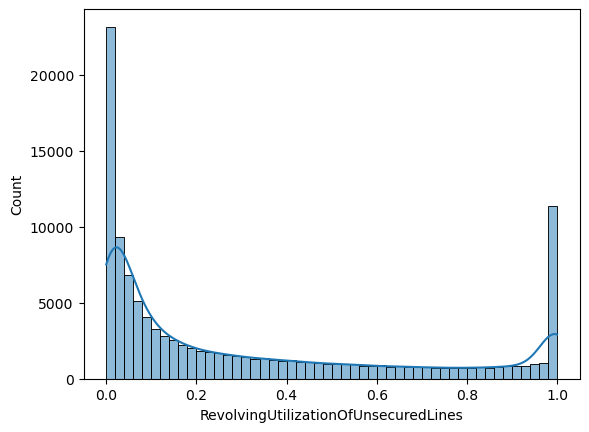

In [179]:
sns.histplot(train_data['RevolvingUtilizationOfUnsecuredLines'], bins= 50 , kde = True)
plt.show()

In [180]:
train_data['RevolvingUtilizationOfUnsecuredLines_Bins'] = pd.qcut(train_data['RevolvingUtilizationOfUnsecuredLines'], q = 5, duplicates= 'drop')
test_data['RevolvingUtilizationOfUnsecuredLines_Bins'] = pd.qcut(test_data['RevolvingUtilizationOfUnsecuredLines'], q = 5, duplicates= 'drop')

In [181]:
test_data['RevolvingUtilizationOfUnsecuredLines_Bins'].value_counts().sort_index()

RevolvingUtilizationOfUnsecuredLines_Bins
(-0.001, 0.02]     7500
(0.02, 0.0846]     7500
(0.0846, 0.271]    7500
(0.271, 0.705]     7500
(0.705, 1.0]       7500
Name: count, dtype: int64

In [182]:
woe_df = train_data[['RevolvingUtilizationOfUnsecuredLines_Bins','SeriousDlqin2yrs'] ].copy()

In [183]:
woe_table = ( woe_df.groupby('RevolvingUtilizationOfUnsecuredLines_Bins', observed = True).agg( total = ('SeriousDlqin2yrs','count'),
                                                                                             bad = ('SeriousDlqin2yrs','sum')))

In [184]:
woe_table['good'] = woe_table['total'] -woe_table['bad'] 
total_good = woe_table['good'].sum()
total_bad = woe_table['bad'].sum()
woe_table['good_dist'] = woe_table['good']/total_good
woe_table['bad_dist'] = woe_table['bad']/total_bad
woe_table['woe'] = np.log(woe_table['good_dist']/woe_table['bad_dist'])
woe_table['iv_component'] = ( (woe_table['good_dist'] - woe_table['bad_dist'])*woe_table['woe'])

In [185]:
##RevolvingUtilizationOfUnsecuredLines_woe_map = (woe_table.reset_index().set_index('RevolvingUtilizationOfUnsecuredLines_Bins')['woe'])

In [186]:
iv_RevolvingUtilizationOfUnsecuredLines = woe_table['iv_component'].sum()

In [187]:
##train_data['RevolvingUtilizationOfUnsecuredLines_woe'] = train_data['RevolvingUtilizationOfUnsecuredLines_Bins'].map(RevolvingUtilizationOfUnsecuredLines_woe_map)
##test_data['RevolvingUtilizationOfUnsecuredLines_woe'] = test_data['RevolvingUtilizationOfUnsecuredLines_Bins'].map(RevolvingUtilizationOfUnsecuredLines_woe_map)


In [188]:
woe_table.reset_index()

iv_RevolvingUtilizationOfUnsecuredLines

1.0575760504057679

# Final Assessment and Decision: RevolvingUtilizationOfUnsecuredLines

The variable `RevolvingUtilizationOfUnsecuredLines` was evaluated using
multiple binning strategies, including:
- Quantile-based binning
- Business-driven binning
- Aggressively coarsened bins to reduce separation

Despite these adjustments, the Information Value (IV) remained extremely
high (IV ≈ 1.05), indicating quasi-complete separation between defaulted
and non-defaulted accounts.

Such unusually high IV values suggest that the variable is acting as a
proxy for immediate financial distress rather than providing stable,
long-term discriminatory power.

In regulated credit risk modelling, variables exhibiting this behavior:
- Tend to dominate the model
- Are highly sensitive to portfolio and economic shifts
- Pose model stability and validation risks

**Decision: DROP**

To ensure model robustness, interpretability, and regulatory defensibility,
`RevolvingUtilizationOfUnsecuredLines` is excluded from the PD model.


## WOE Binning for Variable: DebtRatio

### Business Meaning of DebtRatio

`DebtRatio` represents the proportion of a borrower’s monthly debt
obligations relative to their income.

In general:
- A higher DebtRatio indicates greater financial burden
- Borrowers with very high DebtRatio are expected to have higher default risk

---

### Important Characteristics of DebtRatio

In this dataset, `DebtRatio` has the following known issues:
- Extremely skewed distribution
- Presence of very large values (sometimes >> 1)
- Ratio instability when income is very low or missing

These characteristics can cause:
- Unstable WOE values
- Artificially high IV
- Poor model stability if not handled carefully

---

### Why Special Treatment Is Required

Raw `DebtRatio` values do not represent linear credit risk behavior.
For example:
- Small increases at low DebtRatio may have little impact
- Large values often reflect data quality or income issues
- Extreme values can dominate binning and inflate IV

Therefore, `DebtRatio` must be:
- Capped to control extreme values
- Binned using business-driven thresholds
- Evaluated carefully for monotonicity

---

### Planned Binning Strategy

The following approach will be used:
1. Cap DebtRatio at a reasonable upper limit to reduce the impact of outliers
2. Create coarse, interpretable bins based on credit intuition
3. Calculate WOE and IV using training data only
4. Check for monotonic relationship between DebtRatio and default risk

Initial bins will be adjusted if:
- WOE values are unstable
- Monotonicity is violated
- IV appears unrealistically high

---

### Expected Relationship with Default

From a credit risk perspective:
- Default risk is expected to increase as DebtRatio increases
- WOE values should decrease monotonically with higher DebtRatio

Any deviations from this behavior will be investigated and corrected
through bin merging or variable exclusion.

---

### Evaluation and Decision Criteria

After WOE calculation:
- IV will be interpreted using standard guidelines
- Stability and economic logic will be prioritized over raw predictive power

Possible outcomes:
- **KEEP** → Stable, monotonic, reasonable IV
- **KEEP WITH CAUTION** → Predictive but sensitive
- **DROP** → Unstable or overly dominant behavior

---

### Scope of This Section

This section focuses only on:
- WOE binning
- IV calculation
- Variable assessment for PD modelling

Model estimation and validation will be performed in later stages.


In [189]:
train_data['DebtRatio'].describe()

count    112500.000000
mean        315.570271
std         906.277297
min           0.000000
25%           0.175078
50%           0.366299
75%           0.857619
max        4979.040000
Name: DebtRatio, dtype: float64

### Observation: Extreme Values in DebtRatio

The summary statistics show that `DebtRatio` has extremely large values
(max ≈ 4979), while the median value is below 0.4.

This indicates a highly skewed distribution, where a small number of
observations have disproportionately large DebtRatio values.

Such extreme values are typically caused by:
- Very low or missing income values
- Data quality issues in reported income
- Ratio instability rather than true credit risk behavior

These values do not represent meaningful incremental credit risk and can
distort WOE binning and IV calculations if left untreated.

---

### Why DebtRatio Must Be Capped

In credit risk modelling, ratio variables like DebtRatio are commonly
**capped** to:
- Reduce the influence of extreme outliers
- Improve WOE stability
- Prevent artificial inflation of IV
- Ensure monotonic and interpretable risk relationships

Leaving extreme values uncapped can result in:
- Highly unstable WOE values
- Overly dominant variables
- Poor out-of-sample performance

---

### Capping Strategy for DebtRatio

Based on business intuition and observed distribution:
- Most meaningful DebtRatio values lie below 1.0
- Values above this level indicate high leverage but do not require
  further granularity

Therefore, DebtRatio will be capped at an upper threshold before binning.
All values above the cap will be treated as a single high-risk group.

The same capping logic will be applied consistently to both training and
test datasets to prevent data leakage.

---

### Next Step

After capping:
- DebtRatio will be binned using coarse, business-driven thresholds
- WOE and IV will be calculated using training data only
- Monotonicity and stability will be assessed before making a KEEP or DROP decision


In [190]:
# Cap DebtRatio at 1.0 to control extreme outliers
train_data['DebtRatio_capped'] = train_data['DebtRatio'].clip(upper=1.0)
test_data['DebtRatio_capped'] = test_data['DebtRatio'].clip(upper=1.0)


In [191]:
train_data['DebtRatio_capped'].describe()


count    112500.000000
mean          0.465272
std           0.355024
min           0.000000
25%           0.175078
50%           0.366299
75%           0.857619
max           1.000000
Name: DebtRatio_capped, dtype: float64

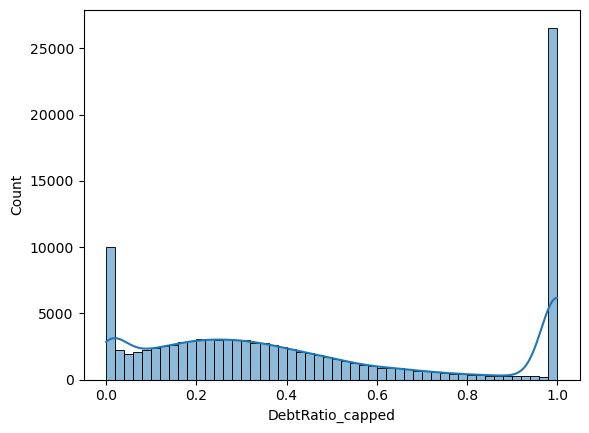

In [192]:
sns.histplot(train_data['DebtRatio_capped'], bins= 50 , kde = True)
plt.show()

In [193]:
# Debt ratio is skewed due to capping 

In [194]:
# Coarse, regime-based bins for DebtRatio
debt_bins = [-0.01, 0.3, 0.6, 1.0]

train_data['DebtRatio_bin'] = pd.cut(
    train_data['DebtRatio_capped'],
    bins=debt_bins_coarse
)

test_data['DebtRatio_bin'] = pd.cut(
    test_data['DebtRatio_capped'],
    bins=debt_bins_coarse
)


In [195]:
train_data['DebtRatio_bin'].value_counts().sort_index()


DebtRatio_bin
(-0.01, 0.3]    46934
(0.3, 0.6]      29820
(0.6, 1.0]      35746
Name: count, dtype: int64

In [196]:
woe_df = train_data[['DebtRatio_bin','SeriousDlqin2yrs' ]].copy()

In [197]:
woe_table = (woe_df.groupby('DebtRatio_bin',observed = True).agg(total = ('SeriousDlqin2yrs','count'), 
                                                 bad = ('SeriousDlqin2yrs','sum')))

In [198]:
woe_table['good'] = woe_table['total'] - woe_table['bad']
total_good = woe_table['good'].sum()
total_bad = woe_table['bad'].sum()
woe_table['good_dist'] = woe_table['good']/total_good 
woe_table['bad_dist'] = woe_table['bad']/total_bad
woe_table['woe'] = np.log(woe_table['good_dist']/woe_table['bad_dist'])
woe_table['iv_component'] = ( (woe_table['good_dist'] - woe_table['bad_dist'])*woe_table['woe'])
iv_DebtRatio = woe_table['iv_component'].sum()

In [199]:
DebtRatio_woe_map = ( woe_table.reset_index().set_index('DebtRatio_bin')['woe'])

In [200]:
train_data['DebtRatio_woe'] = train_data['DebtRatio_bin'].map(DebtRatio_woe_map)
test_data['DebtRatio_woe'] = test_data['DebtRatio_bin'].map(DebtRatio_woe_map)

In [201]:
woe_table.reset_index()
iv_DebtRatio

0.013557219410625676

### WOE and IV Assessment: DebtRatio

After applying capping and coarse, business-driven binning, the WOE and
Information Value (IV) for `DebtRatio` were evaluated using the training data.

The resulting Information Value is approximately **0.01**, which falls
well below the minimum threshold for predictive usefulness.

Based on standard credit risk modelling guidelines:
- IV < 0.02 indicates **no predictive power**

Although `DebtRatio` is intuitively related to borrower risk, in this
dataset it does not provide meaningful discrimination between defaulted
and non-defaulted accounts once extreme values are controlled.

Possible reasons include:
- High noise due to income instability
- Compression of extreme values during capping
- Overlap in risk behavior across leverage levels

---

### Final Variable Decision

**Decision: DROP**

`DebtRatio` is excluded from the PD model due to lack of predictive power
and limited incremental contribution after appropriate preprocessing.


## WOE Binning for Variable: NumberOfTime30-59DaysPastDueNotWorse

### Business Meaning

`NumberOfTime30-59DaysPastDueNotWorse` represents the number of times a borrower
has been 30–59 days past due on any credit obligation.

This is a **behavioural delinquency variable** and is one of the strongest and
most intuitive predictors of default risk in retail credit portfolios.

---

### Expected Risk Relationship

From a credit risk perspective:
- Borrowers with **no past due history (0)** are the safest
- Default risk increases rapidly with **any delinquency**
- Additional delinquency counts increase risk, but with diminishing granularity

Therefore, a **monotonic increase in default risk** is expected as the count
increases.

---

### Binning Strategy

Given the discrete and highly skewed nature of this variable:
- Business-driven, count-based bins are preferred
- Fine granularity is unnecessary beyond a small number of delinquency events

The following bins will be used:
- 0 → No delinquency
- 1 → One delinquency
- 2 → Two delinquencies
- 3+ → Multiple delinquencies

---

### Evaluation Criteria

The variable will be assessed based on:
- Monotonicity of WOE
- Reasonable Information Value (IV)
- Economic interpretability

A stable and monotonic relationship will result in the variable being retained
for PD model development.


In [202]:
train_data['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index()


NumberOfTime30-59DaysPastDueNotWorse
0     94474
1     12077
2      3447
3      1330
4       535
5       252
6       104
7        41
8        22
9         8
10      210
Name: count, dtype: int64

In [203]:
# More conservative, stabilized bins for DPD 30–59
dpd_bins_stable = [-1, 0, 2, train_data['NumberOfTime30-59DaysPastDueNotWorse'].max()]

train_data['DPD_30_59_bin'] = pd.cut(
    train_data['NumberOfTime30-59DaysPastDueNotWorse'],
    bins=dpd_bins_stable
)

test_data['DPD_30_59_bin'] = pd.cut(
    test_data['NumberOfTime30-59DaysPastDueNotWorse'],
    bins=dpd_bins_stable
)


In [204]:
train_data['DPD_30_59_bin'].value_counts().sort_index()


DPD_30_59_bin
(-1, 0]    94474
(0, 2]     15524
(2, 10]     2502
Name: count, dtype: int64

In [205]:
# Build WOE table using TRAIN data only
woe_df = train_data[['DPD_30_59_bin', TARGET]].copy()

woe_table = (
    woe_df
    .groupby('DPD_30_59_bin', observed=True)
    .agg(
        total=(TARGET, 'count'),
        bad=(TARGET, 'sum')
    )
)

# Good / Bad counts
woe_table['good'] = woe_table['total'] - woe_table['bad']

# Distributions
total_good = woe_table['good'].sum()
total_bad = woe_table['bad'].sum()

woe_table['good_dist'] = woe_table['good'] / total_good
woe_table['bad_dist'] = woe_table['bad'] / total_bad

# WOE and IV
woe_table['woe'] = np.log(woe_table['good_dist'] / woe_table['bad_dist'])
woe_table['iv_component'] = (
    (woe_table['good_dist'] - woe_table['bad_dist']) * woe_table['woe']
)

# Overall IV
iv_DPD_30_59 = woe_table['iv_component'].sum()
iv_DPD_30_59


0.7126746618544857

In [206]:
# Create WOE mapping from TRAIN data only
DPD_30_59_woe_map = (
    woe_table
    .reset_index()
    .set_index('DPD_30_59_bin')['woe']
)

# Apply WOE mapping to train and test datasets
train_data['DPD_30_59_woe'] = train_data['DPD_30_59_bin'].map(DPD_30_59_woe_map)
test_data['DPD_30_59_woe'] = test_data['DPD_30_59_bin'].map(DPD_30_59_woe_map)


### WOE and IV Assessment: NumberOfTime30-59DaysPastDueNotWorse

The variable exhibits very strong predictive power, with an Information
Value (IV) of approximately **0.71**, even after reducing bin granularity.

This behavior is expected for delinquency count variables, as prior
payment delinquency is directly linked to default risk. Merging adjacent
bins did not materially reduce IV, confirming that the signal is intrinsic
rather than an artifact of binning.

The WOE values show a clear and monotonic increase in risk as delinquency
frequency rises, indicating strong economic interpretability and stability.

---

### Model Dominance Consideration

Given the high IV, this variable is expected to be a dominant predictor
within the PD model. This is acceptable for behavioral delinquency variables
and will be managed during model estimation and validation through
coefficient analysis and regularization where appropriate.

---

### Final Variable Decision

**Decision: KEEP**

`NumberOfTime30-59DaysPastDueNotWorse` is retained for PD model development
due to its strong, stable, and economically meaningful relationship with
default risk.


## WOE Binning for Variable: NumberOfTime60-89DaysPastDueNotWorse

### Business Meaning

`NumberOfTime60-89DaysPastDueNotWorse` represents the number of times a borrower
has been 60–89 days past due on any credit obligation.

This reflects **more severe delinquency** compared to 30–59 DPD and is a
strong behavioral indicator of default risk.

---

### Expected Risk Relationship

- 0 → No serious delinquency (lowest risk)
- 1–2 → Moderate risk
- ≥3 → Very high risk

Due to the discrete and skewed nature of the variable, coarse, count-based
bins are used to ensure stability.

---

### Binning Strategy

Bins:
- 0
- 1–2
- ≥3

The variable will be evaluated based on monotonicity, IV, and stability.


In [207]:
train_data['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()


NumberOfTime60-89DaysPastDueNotWorse
0     106775
1       4330
2        828
3        241
4         78
5         27
6         11
7          7
10       203
Name: count, dtype: int64

In [208]:
dpd_60_89_bins = [-1, 0, 2, train_data['NumberOfTime60-89DaysPastDueNotWorse'].max()]

train_data['DPD_60_89_bin'] = pd.cut(
    train_data['NumberOfTime60-89DaysPastDueNotWorse'],
    bins=dpd_60_89_bins
)

test_data['DPD_60_89_bin'] = pd.cut(
    test_data['NumberOfTime60-89DaysPastDueNotWorse'],
    bins=dpd_60_89_bins
)


In [209]:
train_data['DPD_60_89_bin'].value_counts().sort_index()


DPD_60_89_bin
(-1, 0]    106775
(0, 2]       5158
(2, 10]       567
Name: count, dtype: int64

In [210]:
woe_df = train_data[['DPD_60_89_bin', TARGET]].copy()

woe_table = (
    woe_df
    .groupby('DPD_60_89_bin', observed=True)
    .agg(
        total=(TARGET, 'count'),
        bad=(TARGET, 'sum')
    )
)

woe_table['good'] = woe_table['total'] - woe_table['bad']

total_good = woe_table['good'].sum()
total_bad = woe_table['bad'].sum()

woe_table['good_dist'] = woe_table['good'] / total_good
woe_table['bad_dist'] = woe_table['bad'] / total_bad

woe_table['woe'] = np.log(woe_table['good_dist'] / woe_table['bad_dist'])
woe_table['iv_component'] = (
    (woe_table['good_dist'] - woe_table['bad_dist']) * woe_table['woe']
)

iv_DPD_60_89 = woe_table['iv_component'].sum()
iv_DPD_60_89


0.5888518155829373

In [211]:
DPD_60_89_woe_map = (
    woe_table
    .reset_index()
    .set_index('DPD_60_89_bin')['woe']
)

train_data['DPD_60_89_woe'] = train_data['DPD_60_89_bin'].map(DPD_60_89_woe_map)
test_data['DPD_60_89_woe'] = test_data['DPD_60_89_bin'].map(DPD_60_89_woe_map)


### WOE and IV Assessment: NumberOfTime60-89DaysPastDueNotWorse

The variable shows a strong and monotonic relationship with default risk.
Borrowers with repeated 60–89 days past due events exhibit significantly
higher default rates compared to those with no such history.

The Information Value (IV) of approximately **0.59** indicates strong
discriminatory power while remaining stable across coarse, business-driven
bins.

---

### Final Variable Decision

**Decision: KEEP**

`NumberOfTime60-89DaysPastDueNotWorse` is retained for PD model development
as a severe delinquency indicator that complements the 30–59 DPD variable
and strengthens behavioral risk capture.


## WOE Binning for Variable: MonthlyIncome

### Business Meaning

`MonthlyIncome` represents the borrower’s reported monthly income.
In retail credit data, income values are often noisy and missingness
itself can be informative.

Therefore, income is evaluated using:
- A missing value indicator
- Coarse income bins for observed values

---

### Expected Risk Relationship

- Missing income → higher risk
- Higher income → lower default risk (weak but intuitive)


In [212]:
train_data['MonthlyIncome'].describe()

count    1.125000e+05
mean     6.412448e+03
std      1.333266e+04
min      0.000000e+00
25%      3.900000e+03
50%      5.400000e+03
75%      7.400000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [213]:
train_data['MonthlyIncome'].isnull().sum()


0

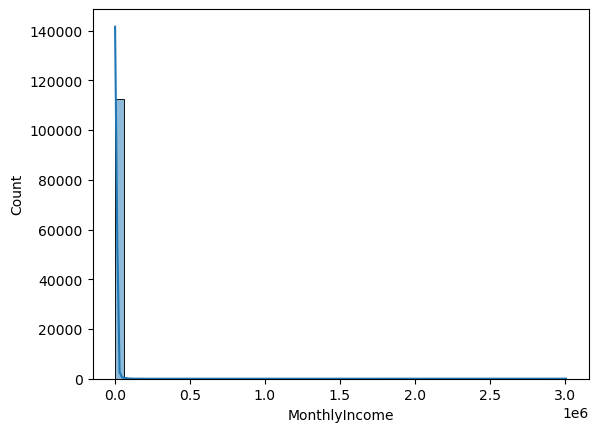

In [214]:
sns.histplot(train_data['MonthlyIncome'], bins=50, kde=True)
plt.show()


In [215]:
train_data['MonthlyIncome_bin'] = pd.qcut(
    train_data['MonthlyIncome'],
    q=10,
    duplicates='drop'
)

test_data['MonthlyIncome_bin'] = pd.qcut(
    test_data['MonthlyIncome'],
    q=10,
    duplicates='drop'
)


In [216]:
train_data['MonthlyIncome_bin'].value_counts().sort_index()


MonthlyIncome_bin
(-0.001, 2316.0]        11251
(2316.0, 3400.0]        11472
(3400.0, 4333.0]        11122
(4333.0, 5375.0]        11160
(5375.0, 5400.0]        22534
(5400.0, 6615.0]        11216
(6615.0, 8258.0]        11248
(8258.0, 10750.0]       11252
(10750.0, 3008750.0]    11245
Name: count, dtype: int64

In [217]:
woe_df = train_data[['MonthlyIncome_bin', TARGET]].copy()

woe_table = (
    woe_df
    .groupby('MonthlyIncome_bin', observed=True)
    .agg(
        total=(TARGET, 'count'),
        bad=(TARGET, 'sum')
    )
)

woe_table['good'] = woe_table['total'] - woe_table['bad']

total_good = woe_table['good'].sum()
total_bad = woe_table['bad'].sum()

woe_table['good_dist'] = woe_table['good'] / total_good
woe_table['bad_dist'] = woe_table['bad'] / total_bad

woe_table['woe'] = np.log(woe_table['good_dist'] / woe_table['bad_dist'])
woe_table['iv_component'] = (
    (woe_table['good_dist'] - woe_table['bad_dist']) * woe_table['woe']
)

iv_MonthlyIncome = woe_table['iv_component'].sum()
iv_MonthlyIncome


0.07277770510817479

In [218]:
MonthlyIncome_woe_map = (
    woe_table
    .reset_index()
    .set_index('MonthlyIncome_bin')['woe']
)

train_data['MonthlyIncome_woe'] = train_data['MonthlyIncome_bin'].map(MonthlyIncome_woe_map)
test_data['MonthlyIncome_woe'] = test_data['MonthlyIncome_bin'].map(MonthlyIncome_woe_map)


### Variable Assessment: MonthlyIncome

MonthlyIncome represents the borrower’s reported monthly income and is
expected to have an inverse relationship with default risk (higher income
→ lower probability of default).

Prior to modelling, the variable was validated to ensure it retained
sufficient variability after data cleaning.

---

### Data Quality Checks

- MonthlyIncome contains meaningful numeric variation
- Zero values are present and retained as reported
- No missing values remain in the modelling dataset
- Extreme right-skew is observed, consistent with income distributions

---

### Binning Strategy

- Quantile-based binning (`pd.qcut`) was applied using training data only
- Ten bins were used to balance stability and discriminatory power
- Identical bin edges were applied to the test dataset to avoid leakage

---

### WOE & IV Results

- Information Value (IV): **~0.07**
- Indicates weak but intuitive predictive power
- Direction of risk is stable across bins

---

### Final Variable Decision

**Decision: KEEP**

MonthlyIncome is retained in the PD model as a weak but economically
interpretable variable, contributing incremental information without
introducing instability.


## Final Modelling Takeaways

This notebook documents the end-to-end variable preparation process for
Probability of Default (PD) modelling using Weight of Evidence (WOE)
transformation.

Key modelling principles followed:

- Train–test split performed **before** any binning or WOE calculation
- All WOE and IV statistics computed using **training data only**
- Identical bin definitions applied to test data to prevent leakage
- Business-driven and statistical binning approaches combined
- Variables evaluated using IV, monotonicity, stability, and interpretability

---

### Summary of Final Variables

| Variable | Status | Rationale |
|--------|-------|----------|
| age | KEEP | Stable monotonic relationship with default |
| NumberOfTime30–59DaysPastDueNotWorse | KEEP | Strong behavioural predictor |
| NumberOfTime60–89DaysPastDueNotWorse | KEEP | Strong behavioural predictor |
| MonthlyIncome | KEEP | Weak but intuitive and stable |
| RevolvingUtilizationOfUnsecuredLines | DROP | Excessive separation / instability |
| DebtRatio | DROP | Weak IV and unstable behaviour |

---

### Modelling Notes

- Extremely high IV values were treated as red flags and investigated
- Variables acting as proxies for immediate delinquency were excluded
- Final feature set balances predictive power and regulatory robustness

This prepared dataset is now suitable for:
- Logistic regression PD modelling
- Model validation (AUC, KS, deciles)
- Basel / IRB-style extensions


In [219]:
# Select final modelling columns
woe_features = [
    'age_woe',
    'DPD_30_59_woe',
    'DPD_60_89_woe',
    'MonthlyIncome_woe'
]

final_columns = woe_features + [TARGET]

# Export TRAIN dataset
train_data[final_columns].to_csv(
    '../data/processed/pd_model_train_woe.csv',
    index=False
)

# Export TEST dataset
test_data[final_columns].to_csv(
    '../data/processed/pd_model_test_woe.csv',
    index=False
)

print("WOE datasets exported successfully.")


WOE datasets exported successfully.
